# Tutorial: Quantum Circuits with Qiskit

## Overview

This tutorial introduces the core tools for building, inspecting, and running
quantum circuits in Qiskit. Starting from a single qubit and a single gate,
we build up to running circuits on multiple simulators and reading the results.

**Topics covered:**

| Section | Topic |
|---|---|
| 1 | Single-qubit gates — $X$ and $H$ as matrices and circuits |
| 2 | Statevector evolution — tracking the quantum state step by step |
| 3 | Operators and gate composition — commutativity vs order |
| 4 | Running circuits — `BasicSimulator`, `AerSimulator`, `SamplerV2` |
| 5 | Reading results — counts, probabilities, histograms |

**Prerequisites:** Python, NumPy basics, familiarity with complex numbers.

---

**References:**

| # | Reference |
|---|---|
| [1] | Qiskit documentation: https://docs.quantum.ibm.com |
| [2] | Nielsen & Chuang. *Quantum Computation and Quantum Information*. Cambridge, 2010. |
| [3] | Qiskit Textbook: https://github.com/Qiskit/textbook |


In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator, Statevector
from qiskit.visualization import plot_histogram
from qiskit.providers.basic_provider import BasicSimulator   # Qiskit 1.x
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Imports successful.')


Imports successful.


---
## 1. Single-Qubit Gates: $X$ and $H$

A **quantum gate** is a unitary operation on one or more qubits. The two most
fundamental single-qubit gates are:

**Pauli $X$ gate** (quantum NOT):
$$X = \begin{pmatrix}0 & 1 \\ 1 & 0\end{pmatrix},\qquad
X|0\rangle = |1\rangle,\quad X|1\rangle = |0\rangle$$

**Hadamard gate** $H$ (creates superposition):
$$H = \frac{1}{\sqrt{2}}\begin{pmatrix}1 & 1 \\ 1 & -1\end{pmatrix},\qquad
H|0\rangle = |{+}\rangle = \frac{|0\rangle+|1\rangle}{\sqrt{2}},\quad
H|1\rangle = |{-}\rangle = \frac{|0\rangle-|1\rangle}{\sqrt{2}}$$

In Qiskit, every quantum gate is also an `Operator` — a matrix that can be
extracted from a circuit, composed with other operators, and applied directly
to state vectors.


X gate circuit:


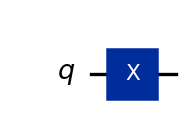

X matrix (Latex):


<IPython.core.display.Latex object>

In [2]:
# ── X gate ──────────────────────────────────────────────────────────────
qc_x = QuantumCircuit(1, name='X gate')
qc_x.x(0)
print('X gate circuit:')
display(qc_x.draw(output='mpl'))

X = Operator(qc_x)
print('X matrix (Latex):')
display(X.draw('latex'))


H gate circuit:


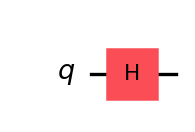

H matrix (Latex):


<IPython.core.display.Latex object>

In [3]:
# ── H gate ──────────────────────────────────────────────────────────────
qc_h = QuantumCircuit(1, name='H gate')
qc_h.h(0)
print('H gate circuit:')
display(qc_h.draw(output='mpl'))

H = Operator(qc_h)
print('H matrix (Latex):')
display(H.draw('latex'))


---
## 2. Statevector Evolution

A **statevector** $|\psi\rangle$ is the complete description of a pure quantum state.
For a single qubit it is a normalised 2-dimensional complex vector:
$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle,\qquad |\alpha|^2 + |\beta|^2 = 1$$

Applying a gate $U$ evolves the state: $|\psi\rangle \xrightarrow{U} U|\psi\rangle$.

We track this step by step for $|0\rangle \xrightarrow{X} |1\rangle$
and $|0\rangle \xrightarrow{H} |{+}\rangle$:


In [4]:
# ── Initial state |0> ────────────────────────────────────────────────────
ket_0 = Statevector.from_label('0')
print('Initial state |0>:')
display(ket_0.draw('latex'))

# ── Apply X: |0> -> |1> ──────────────────────────────────────────────────
ket_1 = ket_0.evolve(X)
print('After X gate — X|0> = |1>:')
display(ket_1.draw('latex'))


Initial state |0>:


<IPython.core.display.Latex object>

After X gate — X|0> = |1>:


<IPython.core.display.Latex object>

In [5]:
# ── Apply H to |0>: -> |+> ───────────────────────────────────────────────
ket_plus = ket_0.evolve(H)
print('After H gate — H|0> = |+>:')
display(ket_plus.draw('latex'))

# ── Apply H to |1>: -> |-> ───────────────────────────────────────────────
ket_minus = ket_1.evolve(H)
print('After H gate — H|1> = |->:')
display(ket_minus.draw('latex'))

print('Probabilities of |+>:', np.round(ket_plus.probabilities(), 4))
print('Probabilities of |->:', np.round(ket_minus.probabilities(), 4))
print('=> Both |+> and |-> give P(0)=P(1)=0.5 when measured in the Z basis.')


After H gate — H|0> = |+>:


<IPython.core.display.Latex object>

After H gate — H|1> = |->:


<IPython.core.display.Latex object>

Probabilities of |+>: [0.5 0.5]
Probabilities of |->: [0.5 0.5]
=> Both |+> and |-> give P(0)=P(1)=0.5 when measured in the Z basis.


Circuit X then H:


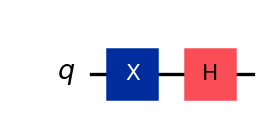

State |0> after X then H:  X|0>=|1>, then H|1>=|->  :


<IPython.core.display.Latex object>

Probabilities: [0.5 0.5]
Sample 100 shots: {np.str_('0'): np.int64(47), np.str_('1'): np.int64(53)}


In [6]:
# ── Build a two-gate circuit: X then H ───────────────────────────────────
# Circuit is read left to right: gates applied in that order.
# As a matrix: the rightmost gate in time = leftmost in matrix product.
# Circuit X -> H  corresponds to the unitary  H * X  (H applied after X).
qc1 = QuantumCircuit(1, name='X then H')
qc1.x(0)    # flip |0> to |1>
qc1.h(0)    # then Hadamard: |1> -> |->  =  (1/sqrt2)(|0> - |1>)
print('Circuit X then H:')
display(qc1.draw(output='mpl'))

q = Statevector(qc1)
print('State |0> after X then H:  X|0>=|1>, then H|1>=|->  :')
display(q.draw('latex'))
print(f'Probabilities: {np.round(q.probabilities(), 4)}')
print(f'Sample 100 shots: {q.sample_counts(100)}')


---
## 3. Operator Composition and Non-Commutativity

Quantum gates, like matrices, generally **do not commute**:
$$X \cdot H \neq H \cdot X$$

The operator `@` in Qiskit applies gates right-to-left (standard matrix
multiplication convention):
- `H @ X` means: apply $X$ first, then $H$ — matches a circuit `x(0)` then `h(0)`.
- `X @ H` means: apply $H$ first, then $X$.

> **Convention reminder:** In Qiskit circuits, gates are drawn and applied
> left-to-right in time. In operator notation (`U = U_2 @ U_1`), the
> rightmost matrix $U_1$ is applied first.


In [7]:
# Build operators from labels
X_op = Operator.from_label('X')
H_op = Operator.from_label('H')

# H @ X: apply X first, then H  (matches circuit: x then h)
HX = H_op @ X_op
print('H @ X  (X first, then H):')
display(HX.draw('latex'))

# X @ H: apply H first, then X
XH = X_op @ H_op
print('X @ H  (H first, then X):')
display(XH.draw('latex'))

print(f'H@X == X@H? {np.allclose(HX.data, XH.data)}')
print('=> Gates do NOT commute: order matters.')


H @ X  (X first, then H):


<IPython.core.display.Latex object>

X @ H  (H first, then X):


<IPython.core.display.Latex object>

H@X == X@H? False
=> Gates do NOT commute: order matters.


In [8]:
# Cross-check: Operator from qc1 circuit (x then h) should equal H@X
U_circuit = Operator(qc1)
print('Operator extracted from qc1 (x then h):')
display(U_circuit.draw('latex'))

print(f'Matches H @ X? {np.allclose(U_circuit.data, HX.data)}')
print('=> Circuit left-to-right = matrix right-to-left. Confirmed.')

# (H@X)(H@X)^dagger = I  — verify unitarity
product = HX.data @ HX.data.conj().T
print(f'\n(H@X)(H@X)^† = I? {np.allclose(product, np.eye(2))}')


Operator extracted from qc1 (x then h):


<IPython.core.display.Latex object>

Matches H @ X? True
=> Circuit left-to-right = matrix right-to-left. Confirmed.

(H@X)(H@X)^† = I? True


---
## 4. Running Circuits: Three Simulators

Qiskit provides several backends for simulating quantum circuits on a classical computer.
They differ in capability, speed, and API:

| Simulator | Module | Best for | Notes |
|---|---|---|---|
| `BasicSimulator` | `qiskit.providers.basic_provider` | Learning, quick checks | Minimal features, fast setup |
| `AerSimulator` | `qiskit_aer` | Research, noise models | Full-featured, supports density matrices |
| `SamplerV2` (Aer) | `qiskit_ibm_runtime` | Primitive-based workflows | Standardised interface, supports batching |

All three run the same quantum circuit — they differ in how you interact with them
and what additional functionality they expose.

We use the simple 1-qubit circuit $X$ then $H$ from Section 2 as the test case.


Circuit to run on all three simulators:


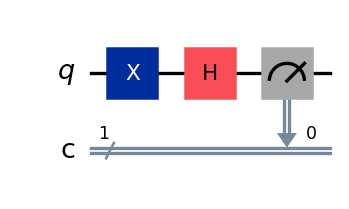

In [9]:
# ── Circuit to run: X then H, then measure ───────────────────────────────
qc_run = QuantumCircuit(1, 1, name='test')
qc_run.x(0)       # flip to |1>
qc_run.h(0)       # create superposition |-> = (|0>-|1>)/sqrt(2)
qc_run.measure(0, 0)   # measure qubit 0 into classical bit 0
print('Circuit to run on all three simulators:')
qc_run.draw(output='mpl')


In [10]:
# ── BasicSimulator ───────────────────────────────────────────────────────
# Lightweight simulator built into Qiskit. Minimal setup.
sim_basic = BasicSimulator()
counts_basic = sim_basic.run(qc_run, shots=1000).result().get_counts()
print(f'BasicSimulator   counts (1000 shots): {counts_basic}')

# ── AerSimulator ─────────────────────────────────────────────────────────
# High-performance simulator from Qiskit Aer. Supports noise models,
# density matrices, and GPU acceleration.
sim_aer = AerSimulator()
counts_aer = sim_aer.run(qc_run, shots=1000).result().get_counts()
print(f'AerSimulator     counts (1000 shots): {counts_aer}')

print()
print('Expected: ~50% |0>, ~50% |1>  (state |->) measures 50/50)')


BasicSimulator   counts (1000 shots): {'0': 499, '1': 501}
AerSimulator     counts (1000 shots): {'1': 519, '0': 481}

Expected: ~50% |0>, ~50% |1>  (state |->) measures 50/50)


In [11]:
# ── SamplerV2 (Aer Primitive) ────────────────────────────────────────────
# The Sampler primitive provides a standardised interface for sampling.
# SamplerV2 accepts a list of circuits and returns a PrimitiveResult.
# Here we use the Aer backend in local mode (no IBM account required).
samp_aer = SamplerV2(mode=sim_aer)

# Run the circuit (pass as a list; multiple circuits can be batched)
result = samp_aer.run([qc_run], shots=1000).result()

# Access results: result[circuit_index].data.classical_register_name
counts_samp = result[0].data.c.get_counts()
print(f'SamplerV2 (Aer) counts (1000 shots): {counts_samp}')


SamplerV2 (Aer) counts (1000 shots): {'0': 495, '1': 505}


---
## 5. Reading Results and Plotting Histograms

All three simulators return **measurement counts**: a dictionary mapping each
bitstring outcome to the number of times it was observed.

For our circuit ($X$ then $H$ on $|0\rangle$):
$$|0\rangle \xrightarrow{X} |1\rangle \xrightarrow{H} |{-}\rangle
= \frac{|0\rangle - |1\rangle}{\sqrt{2}}$$

Measuring $|{-}\rangle$ in the $Z$ basis gives $|0\rangle$ or $|1\rangle$ with equal probability:
$$P(0) = \left|\frac{1}{\sqrt{2}}\right|^2 = \frac{1}{2}, \qquad
P(1) = \left|\frac{-1}{\sqrt{2}}\right|^2 = \frac{1}{2}$$

We expect roughly 50% `'0'` and 50% `'1'` across all three simulators.
Small deviations are due to **shot noise** — finite sampling fluctuations
that vanish as the number of shots increases.


Counts summary:
  BasicSimulator : {'0': 499, '1': 501}
  AerSimulator   : {'1': 519, '0': 481}
  SamplerV2      : {'0': 495, '1': 505}

Theoretical: P(0) = 0.500, P(1) = 0.500


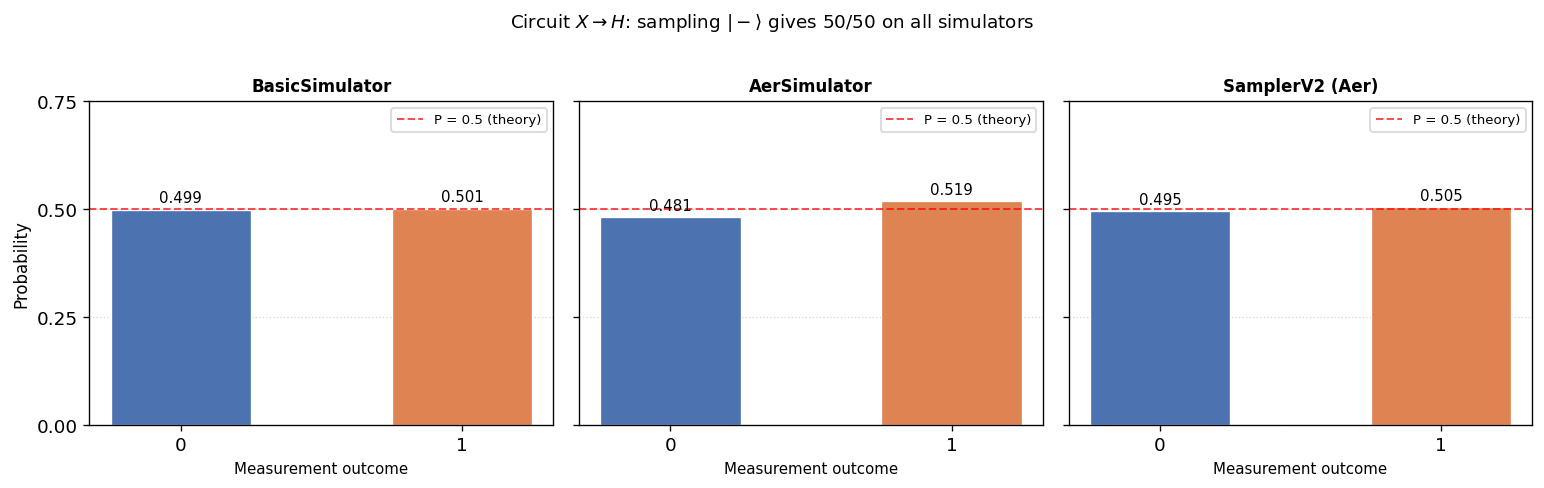

In [13]:
# ── Compare all three simulators side by side ───────────────────────────
# NOTE: plot_histogram() ignores the ax= parameter in most Qiskit versions
# (it always creates its own figure). We use plain matplotlib instead.
import matplotlib.pyplot as plt
import numpy as np

print('Counts summary:')
print(f'  BasicSimulator : {counts_basic}')
print(f'  AerSimulator   : {counts_aer}')
print(f'  SamplerV2      : {counts_samp}')
print()
print('Theoretical: P(0) = 0.500, P(1) = 0.500')

simulators = {
    'BasicSimulator': counts_basic,
    'AerSimulator':   counts_aer,
    'SamplerV2 (Aer)': counts_samp,
}
outcomes   = ['0', '1']
bar_colors = ['#4C72B0', '#DD8452']          # blue for |0>, orange for |1>

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, (sim_name, counts) in zip(axes, simulators.items()):
    total = sum(counts.values())
    probs  = [counts.get(o, 0) / total for o in outcomes]
    bars   = ax.bar(outcomes, probs, color=bar_colors, width=0.5,
                    edgecolor='white', linewidth=0.8)
    # annotate bar tops
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{p:.3f}', ha='center', va='bottom', fontsize=9)
    ax.axhline(0.5, color='red', linestyle='--', linewidth=1.2, alpha=0.7,
               label='P = 0.5 (theory)')
    ax.set_title(sim_name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Measurement outcome', fontsize=9)
    ax.set_ylim(0, 0.75)
    ax.set_yticks(np.arange(0, 0.76, 0.25))
    ax.yaxis.grid(True, linestyle=':', alpha=0.5)
    ax.set_axisbelow(True)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Probability', fontsize=10)
plt.suptitle(
    r'Circuit $X \to H$: sampling $|-\rangle$ gives 50/50 on all simulators',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()


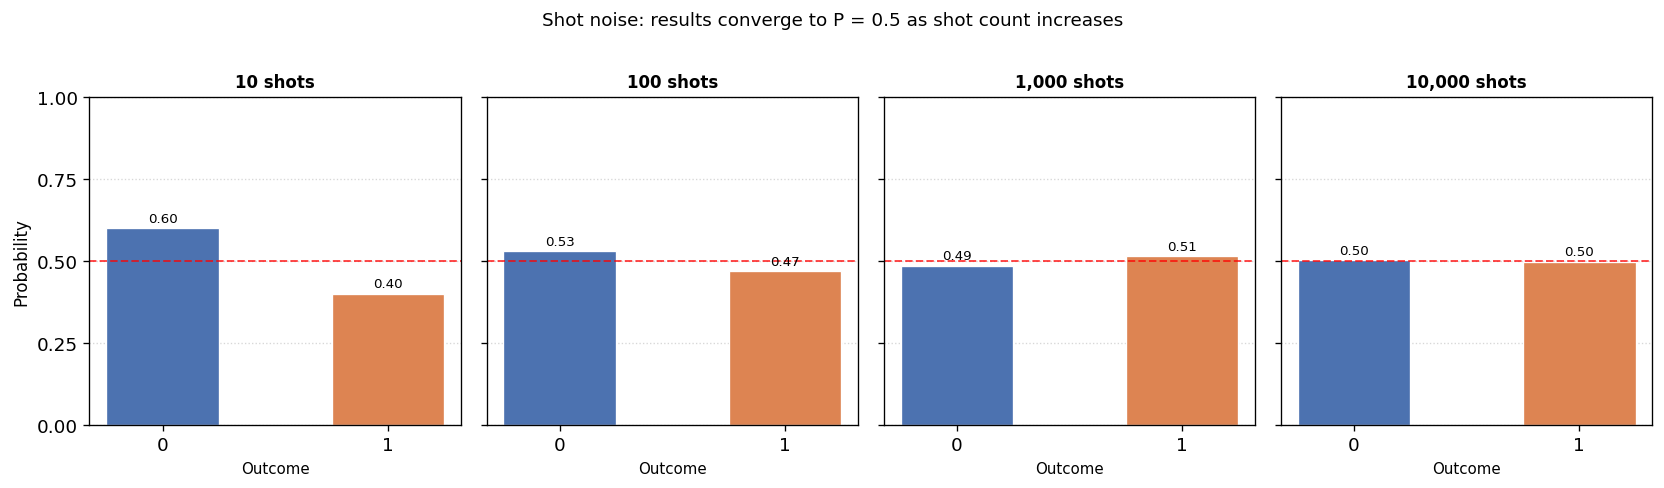

Observation: with few shots the histogram fluctuates;
with many shots it converges to the theoretical P(0)=P(1)=0.5.


In [15]:
# ── Shot noise: how counts converge with more shots ─────────────────────
shot_counts_list = [10, 100, 1000, 10000]
bar_colors = ['#4C72B0', '#DD8452']

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
for ax, n_shots in zip(axes, shot_counts_list):
    c     = sim_aer.run(qc_run, shots=n_shots).result().get_counts()
    total = sum(c.values())
    probs = [c.get(o, 0) / total for o in ['0', '1']]
    bars  = ax.bar(['0', '1'], probs, color=bar_colors, width=0.5,
                   edgecolor='white', linewidth=0.8)
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{p:.2f}', ha='center', va='bottom', fontsize=8)
    ax.axhline(0.5, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.set_title(f'{n_shots:,} shots', fontsize=10, fontweight='bold')
    ax.set_xlabel('Outcome', fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.set_yticks(np.arange(0, 1.01, 0.25))
    ax.yaxis.grid(True, linestyle=':', alpha=0.5)
    ax.set_axisbelow(True)

axes[0].set_ylabel('Probability', fontsize=10)
plt.suptitle(
    'Shot noise: results converge to P = 0.5 as shot count increases',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()

print('Observation: with few shots the histogram fluctuates;')
print('with many shots it converges to the theoretical P(0)=P(1)=0.5.')


---
## Summary

| Concept | Key point |
|---|---|
| Quantum gate | Unitary matrix; applies a reversible transformation to a qubit |
| Statevector | Full description of a pure quantum state; `Statevector.evolve(U)` applies gate $U$ |
| `Operator` | Matrix representation of a gate or circuit; compose with `@` |
| Gate order | **Non-commutative**: $XH \neq HX$; circuit left-to-right = matrix right-to-left |
| `BasicSimulator` | Lightweight; `.run(qc, shots).result().get_counts()` |
| `AerSimulator` | Full-featured; supports noise models and advanced methods |
| `SamplerV2` | Primitive interface; `.run([qc], shots).result()[0].data.c.get_counts()` |
| Shot noise | Finite-sample fluctuations; decreases as $1/\sqrt{N_{\rm shots}}$ |

**Next steps:**
- Add noise models to `AerSimulator` to simulate real hardware (see Chapter 1 of the QEC tutorial)
- Explore multi-qubit circuits: CNOT gate, Bell states, entanglement
- Transpile circuits for specific hardware backends: `transpile(qc, backend)`
- Study the no-cloning theorem tutorial in this series: `no_cloning_theorem.ipynb`
